# LeetCode #205: Isomorphic Strings

https://leetcode.com/problems/isomorphic-strings/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Transformation mapping** | $O(n)$ | $O(n)$ |
| **Optimal: Two hash maps** | $O(n)$ | $O(1)$ (bounded by alphabet) |

---

## Understanding the Methods

### Transformation Mapping
Map each string to a canonical form by replacing each character with the index of its first occurrence. Two strings are isomorphic if they produce the same canonical form. For example, `"egg"` → `[0,1,1]`, `"add"` → `[0,1,1]`.

### Optimal: Two Hash Maps ★
Use two maps: one from `s` chars to `t` chars, and another from `t` chars to `s` chars. For each position:
- If `s[i]` is already mapped to a different `t[i]`, return false.
- If `t[i]` is already mapped to a different `s[i]`, return false.
- Otherwise, establish both mappings.

**Why two maps are needed:** A single map `s→t` would allow two different `s` chars to map to the same `t` char (e.g., `s="ab"`, `t="aa"`). The reverse map prevents this.

**Constraints:**
* `1 <= s.length <= 5 * 10^4`
* `s.length == t.length`
* Strings consist of any valid ASCII character.

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsIsomorphic(string s, string t) {
        var sToT = new Dictionary<char, char>();
        var tToS = new Dictionary<char, char>();
        
        for (int i = 0; i < s.Length; i++) {
            char sc = s[i], tc = t[i];
            
            if (sToT.ContainsKey(sc) && sToT[sc] != tc) return false;
            if (tToS.ContainsKey(tc) && tToS[tc] != sc) return false;
            
            sToT[sc] = tc;
            tToS[tc] = sc;
        }
        
        return true;
    }
}

### Python

In [ ]:
class Solution:
    def isIsomorphic(self, s: str, t: str) -> bool:
        s_to_t = {}
        t_to_s = {}
        
        for sc, tc in zip(s, t):
            if sc in s_to_t and s_to_t[sc] != tc:
                return False
            if tc in t_to_s and t_to_s[tc] != sc:
                return False
            s_to_t[sc] = tc
            t_to_s[tc] = sc
        
        return True

### Go

In [ ]:
func isIsomorphic(s string, t string) bool {
    sToT := make(map[byte]byte)
    tToS := make(map[byte]byte)
    
    for i := 0; i < len(s); i++ {
        sc, tc := s[i], t[i]
        
        if mapped, ok := sToT[sc]; ok && mapped != tc {
            return false
        }
        if mapped, ok := tToS[tc]; ok && mapped != sc {
            return false
        }
        
        sToT[sc] = tc
        tToS[tc] = sc
    }
    
    return true
}

### Rust

In [ ]:
use std::collections::HashMap;

impl Solution {
    pub fn is_isomorphic(s: String, t: String) -> bool {
        let mut s_to_t: HashMap<u8, u8> = HashMap::new();
        let mut t_to_s: HashMap<u8, u8> = HashMap::new();
        
        for (&sc, &tc) in s.as_bytes().iter().zip(t.as_bytes().iter()) {
            if let Some(&mapped) = s_to_t.get(&sc) {
                if mapped != tc { return false; }
            }
            if let Some(&mapped) = t_to_s.get(&tc) {
                if mapped != sc { return false; }
            }
            s_to_t.insert(sc, tc);
            t_to_s.insert(tc, sc);
        }
        
        true
    }
}

## Example Scenarios

1. **Common Case:** `s = "egg"`, `t = "add"` → **true**. Map: $e \leftrightarrow a$, $g \leftrightarrow d$. At index 2, $g \to d$ is checked against existing entry and is consistent. WHY tricky: The repeated mapping at index 2 must be verified against the existing entry — consistency check, not just insertion.

2. **Slightly Complex — Reverse Map Conflict:** `s = "badc"`, `t = "baba"` → **false**. At index 2, $d$ should map to $b$, but $b$ in $t$ is already mapped back to $b$ in $s$ (from index 0). Since $d \neq b$, the reverse map catches it. WHY tricky: The forward map ($s \to t$) would accept $d \to b$ since 'd' is new. Only the REVERSE map ($t \to s$) detects that 'b' in $t$ is already claimed. This is why two maps are essential.

3. **Edge Case — Time Factor (Maximum Length):** `s = "abcabc...abc"` (length $5 \times 10^4$), `t = "xyzxyz...xyz"` (length $5 \times 10^4$) → **true**. The mapping $\{a \leftrightarrow x, b \leftrightarrow y, c \leftrightarrow z\}$ is established in the first 3 chars and verified for the remaining 49,997. Total: $10^5$ hash map lookups. WHY tricky: With $n = 50{,}000$, the vast majority of iterations are verification lookups — hash map operations must be truly $O(1)$ amortized.

4. **Edge Case — Space Factor (Full ASCII):** `s` and `t` each contain all 128 ASCII characters (each unique, $t$ is a permutation of $s$) → **true**. Both maps reach maximum size: 128 entries each. $S(n) = O(|\Sigma|) = O(128) = O(1)$ for fixed ASCII. WHY tricky: Space is $O(|\Sigma|)$, NOT $O(n)$. Even for $n = 50{,}000$, maps hold at most 128 entries each — this distinction matters in interviews.

5. **Almost-Impossible — Same Character Repeated:** `s = "aaa...a"` ($5 \times 10^4$ 'a's), `t = "bbb...b"` ($5 \times 10^4$ 'b's) → **true**. Maps have exactly one entry each: $\{a:b\}$ and $\{b:a\}$. All 50,000 iterations verify this same mapping. WHY tricky: Minimum map entries (1 each) but maximum verification iterations. Tests the degenerate case where maps are near-empty but the consistency-check path runs $n$ times.

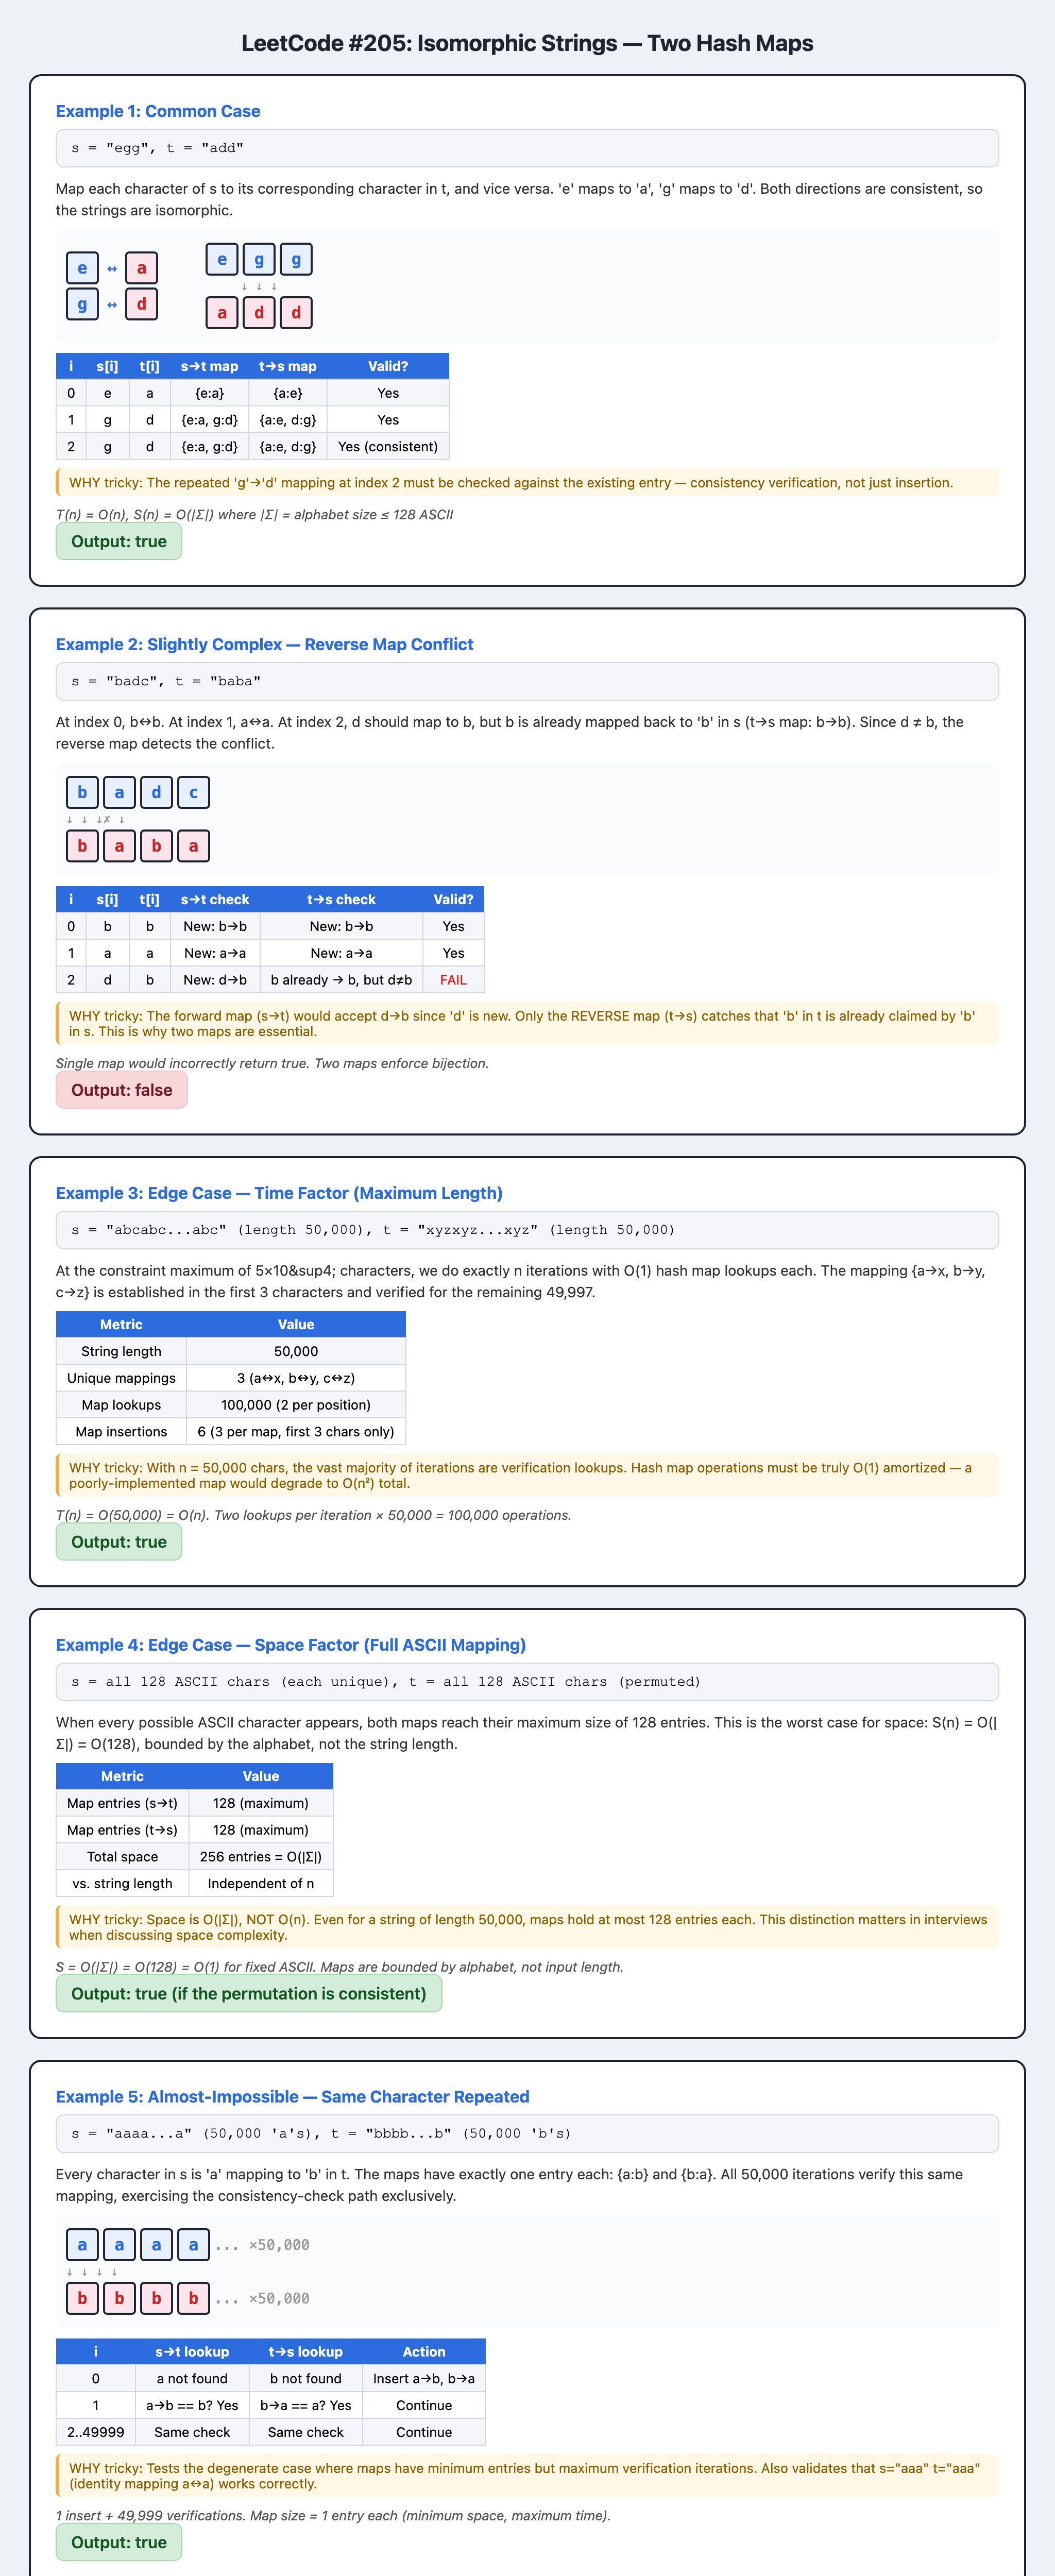